# OptiCrop Project

## Smart Agricultural Production Optimization Engine

### Machine Learning Based Crop Recommendation System

**Project Description**

The OptiCrop project is a Machine Learning-based agricultural recommendation system designed to help farmers identify the most suitable crop based on soil nutrients and environmental conditions. The system analyzes parameters such as Nitrogen (N), Phosphorous (P), Potassium (K), temperature, humidity, pH, and rainfall to recommend the best crop for cultivation.

The project uses data preprocessing, exploratory data analysis (EDA), machine learning algorithms, and a Flask web application to provide accurate crop recommendations. It aims to improve agricultural productivity, optimize resource utilization, and support sustainable farming practices.

# Epic 1 – Define Problem and Understanding

## Story 1: Specify the Business Problem

### Business Problem

Agriculture plays a vital role in food production and economic development. Farmers often face challenges in selecting the most suitable crop because soil nutrients and environmental conditions vary from place to place. Choosing an unsuitable crop can result in reduced yield, financial losses, and inefficient utilization of water, fertilizers, and other agricultural resources.

The objective of the OptiCrop project is to develop a machine learning-based crop recommendation system that analyzes soil and climate parameters such as Nitrogen (N), Phosphorous (P), Potassium (K), temperature, humidity, pH, and rainfall. Based on these parameters, the system recommends the most suitable crop for cultivation, enabling farmers to improve productivity, reduce risks, and adopt sustainable farming practices.

## Story 2: Business Requirements

### Business Requirements

The system should:

- Accept soil parameters such as Nitrogen, Phosphorous, Potassium, temperature, humidity, pH, and rainfall.
- Analyze agricultural data using machine learning algorithms.
- Recommend the most suitable crop based on the given environmental conditions.
- Provide a simple and user-friendly web interface for users.
- Generate accurate and reliable crop predictions in real time.
- Support future enhancements such as cloud deployment and smart farming integration.

## Story 3: Literature Survey

### Literature Survey

Several machine learning techniques have been applied in agriculture to improve crop recommendation and yield prediction. Algorithms such as Decision Tree, Random Forest, K-Nearest Neighbors (KNN), Logistic Regression, and K-Means Clustering have been widely used for analyzing soil and environmental data.

Studies show that machine learning models can significantly improve crop selection by analyzing historical agricultural datasets. These techniques assist farmers in making data-driven decisions, improving productivity, reducing crop failure, and promoting sustainable agricultural practices.

## Story 4: Social and Business Impact

### Social and Business Impact

The OptiCrop system contributes to sustainable agriculture by helping farmers select suitable crops based on soil and environmental conditions. This improves agricultural productivity, reduces farming risks, and increases profitability.

The project also benefits agricultural researchers, policymakers, and agribusiness organizations by providing valuable insights for crop planning and resource management. Efficient crop recommendations help optimize water usage, fertilizer consumption, and soil nutrient management while promoting environmentally friendly farming practices.

# Epic 2 – Data Collection and Analysis

## Story 1: Importing the Libraries

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.cluster import KMeans

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import pickle

plt.style.use("fivethirtyeight")

## Story 2: Read the Dataset

In [6]:
df = pd.read_csv("../dataset/Crop_recommendation.csv")

In [7]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


## Story 3: Explore the Dataset

In [8]:
df.shape

(2200, 8)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 137.6 KB


In [10]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [11]:
df.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='str')

In [12]:
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

## Story 4: Univariate Analysis

### Univariate Analysis

Univariate analysis is performed to study the distribution of individual agricultural features. It helps understand the range, spread, and frequency of each parameter in the crop recommendation dataset.

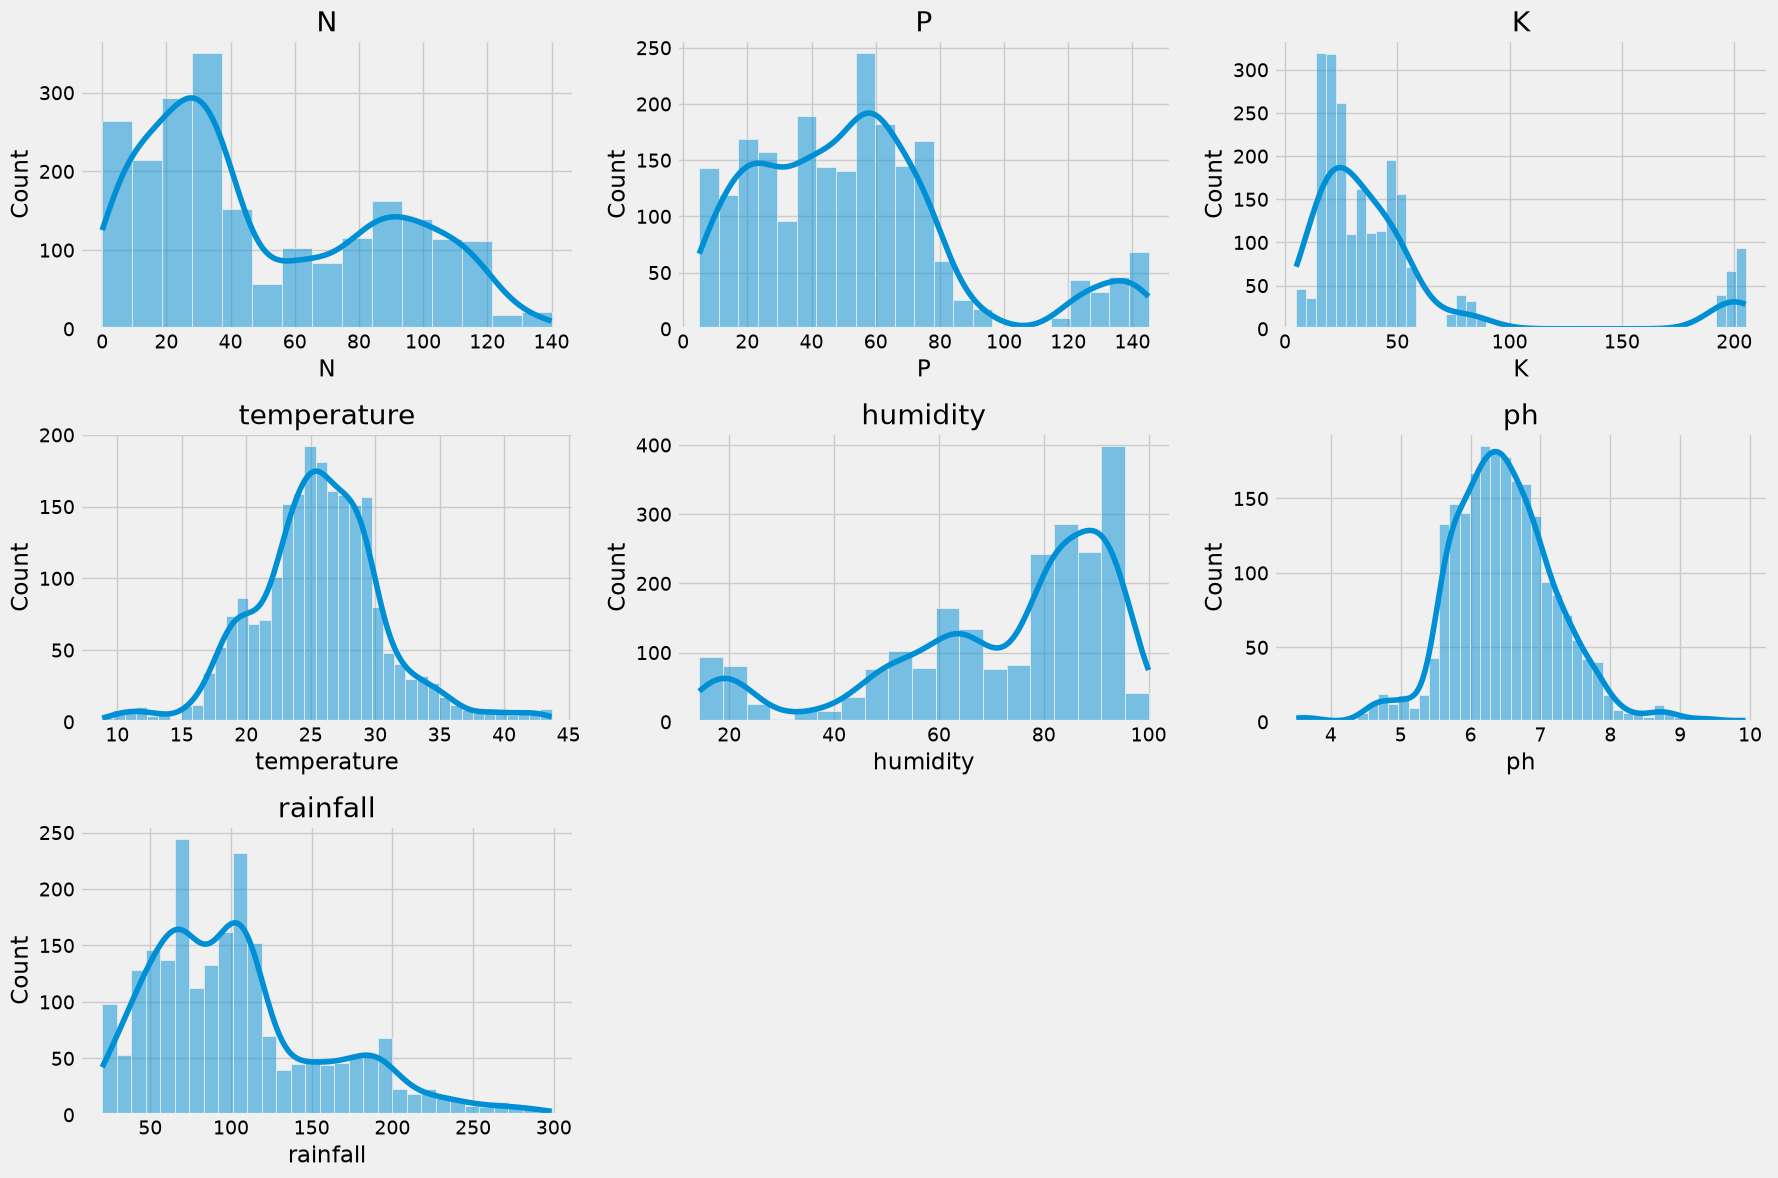

In [13]:
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

plt.figure(figsize=(18,12))

for i, feature in enumerate(features):
    plt.subplot(3,3,i+1)
    sns.histplot(df[feature], kde=True)
    plt.title(feature)

plt.tight_layout()
plt.show()

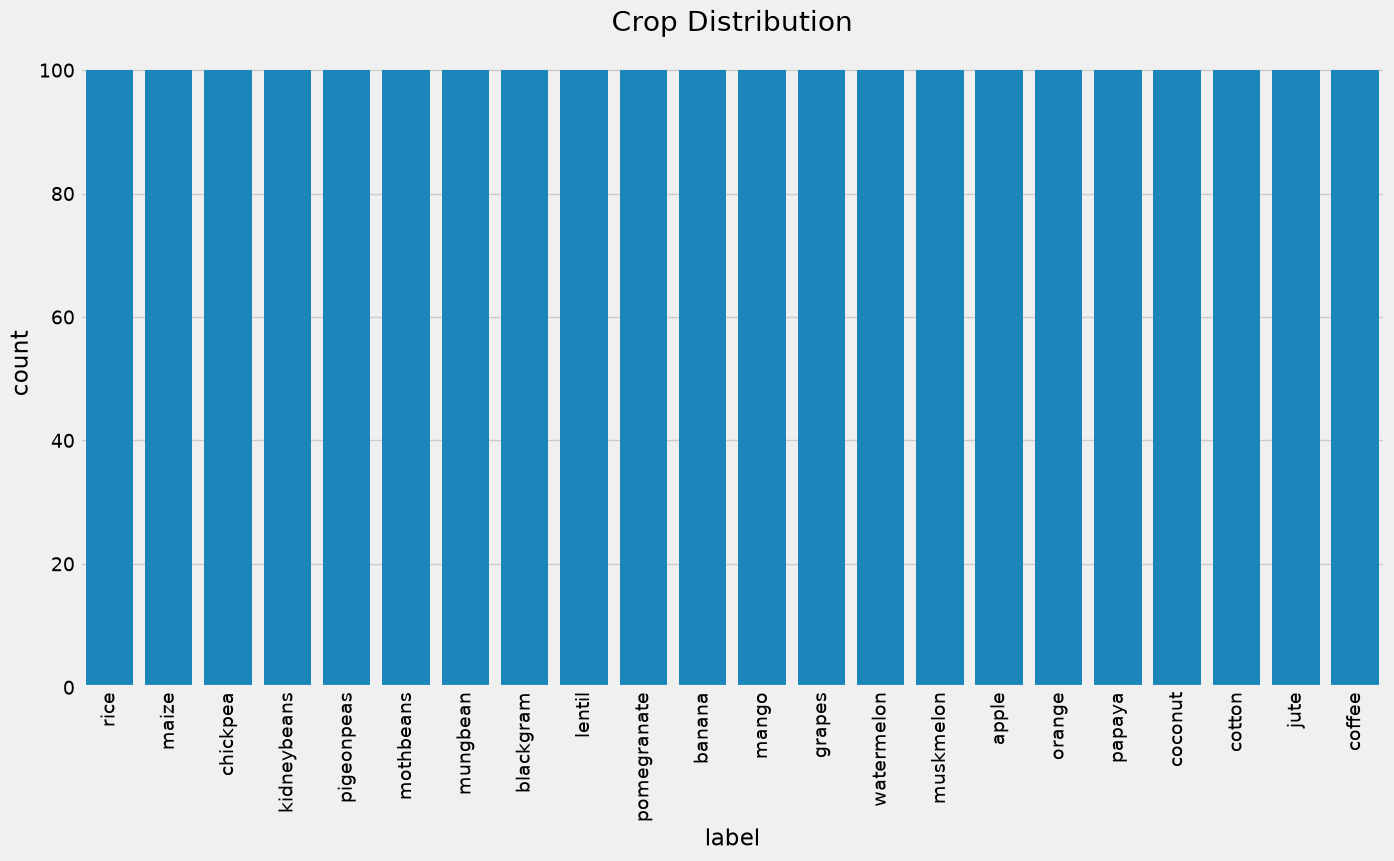

In [14]:
plt.figure(figsize=(15,8))

sns.countplot(x='label', data=df)

plt.xticks(rotation=90)

plt.title("Crop Distribution")

plt.show()

## Story 5: Bivariate Analysis

### Bivariate Analysis

Bivariate analysis is used to understand the relationship between two variables. Here, the relationship between humidity and crop type is visualized using a scatter plot.

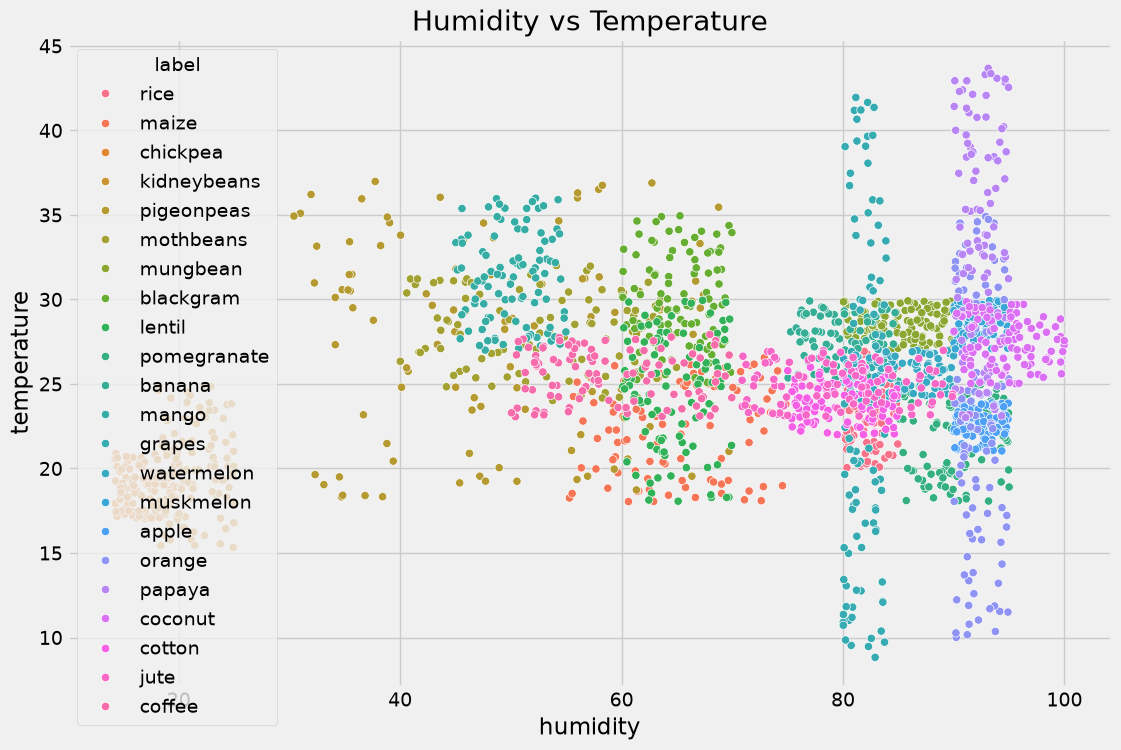

In [15]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    x='humidity',
    y='temperature',
    hue='label',
    data=df
)

plt.title("Humidity vs Temperature")

plt.show()

## Story 6: Multivariate Analysis

### Multivariate Analysis

Multivariate analysis helps understand relationships among multiple agricultural parameters simultaneously. A correlation heatmap is used to identify feature relationships.

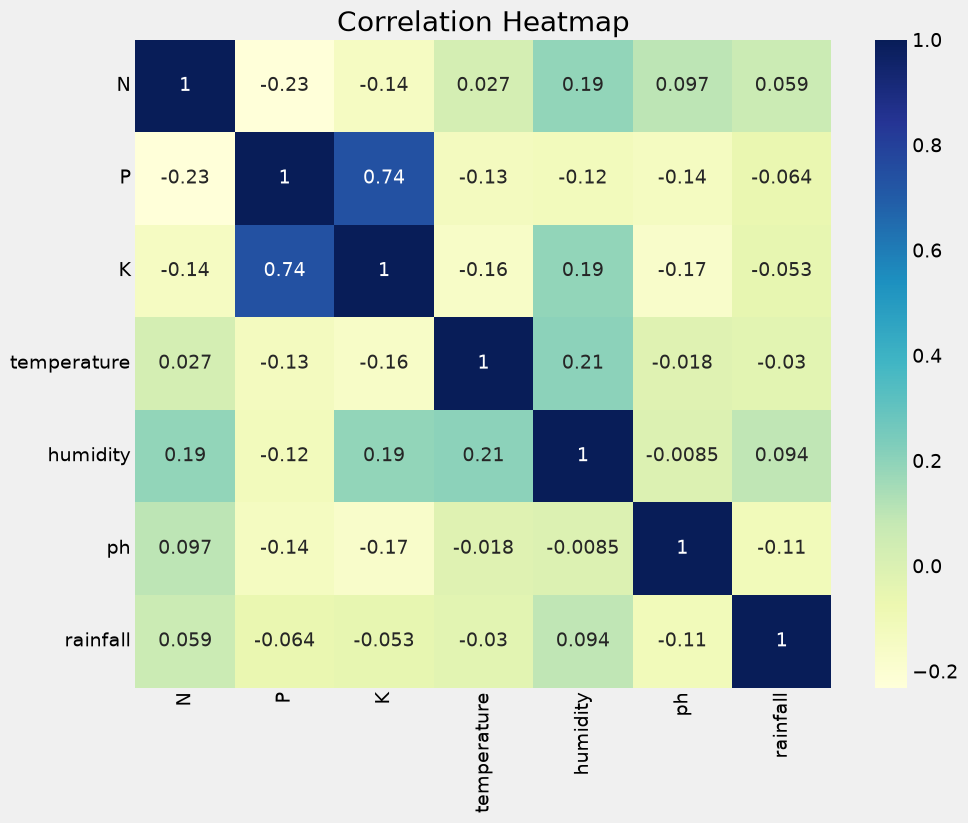

In [16]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="YlGnBu"
)

plt.title("Correlation Heatmap")

plt.show()

# Epic 3 – Data Pre-processing

## Story 1: Checking for Null Values

### Objective

The dataset is examined before preprocessing to identify missing values, verify data types, and understand the dataset structure. This ensures that the agricultural dataset is clean and suitable for machine learning.

In [17]:
df.shape

(2200, 8)

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 137.6 KB


In [19]:
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

### Observation

- The dataset contains **2200 records** and **8 columns**.
- All features have appropriate data types.
- No missing or null values are present in the dataset.
- Therefore, no missing value treatment is required before model building.

## Story 2: Handling Outliers

### Objective

Outliers are identified using boxplots. The Interquartile Range (IQR) method is used to calculate lower and upper bounds. Outliers are then removed from the dataset before machine learning.

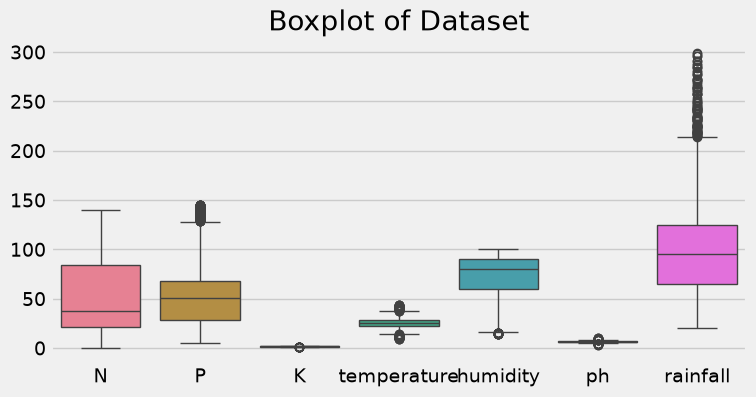

In [35]:
plt.figure(figsize=(8,4))

sns.boxplot(data=df)

plt.title("Boxplot of Dataset")

plt.show()

In [36]:
Q1 = df['P'].quantile(0.25)

Q3 = df['P'].quantile(0.75)

IQR = Q3 - Q1

print("Q1 =",Q1)
print("Q3 =",Q3)
print("IQR =",IQR)

Q1 = 28.0
Q3 = 68.0
IQR = 40.0


In [37]:
filter = (
    (df['P'] > Q1 - 1.5 * IQR)
    &
    (df['P'] <= Q3 + 1.5 * IQR)
)

In [38]:
df = df.loc[filter]

In [39]:
df.shape

(2062, 9)

### Observation

The IQR method was applied to identify outliers in the Phosphorous feature. Records outside the acceptable range were removed, reducing the dataset size from 2200 to approximately 2062 records.

## Story 3: Extracting Seasonal Crops

### Objective

Seasonal crops are identified based on environmental conditions such as temperature, humidity, and rainfall. This helps recommend suitable crops for Summer, Winter, and Rainy seasons.

In [40]:
print("Summer Crops")

print(df[(df['temperature'] > 30) &
         (df['humidity'] > 50)]
      ['label'].unique())

print("----------------")

Summer Crops
<StringArray>
['pigeonpeas', 'mothbeans', 'blackgram', 'mango', 'grapes', 'orange',
 'papaya']
Length: 7, dtype: str
----------------


In [41]:
print("Winter Crops")

print(df[(df['temperature'] < 20) &
         (df['humidity'] > 30)]
      ['label'].unique())

print("----------------")

Winter Crops
<StringArray>
['maize', 'pigeonpeas', 'lentil', 'pomegranate', 'grapes', 'orange']
Length: 6, dtype: str
----------------


In [42]:
print("Rainy Crops")

print(df[(df['rainfall'] > 200) &
         (df['humidity'] > 50)]
      ['label'].unique())

print("----------------")

Rainy Crops
<StringArray>
['rice', 'papaya', 'coconut']
Length: 3, dtype: str
----------------


### Observation

The dataset was filtered using environmental conditions to identify crops suitable for Summer, Winter, and Rainy seasons. This seasonal analysis helps improve crop recommendations based on climate conditions.

## Story 4: Splitting Data into Train and Test Sets

### Objective

The dataset is divided into feature variables (X) and target variable (y). The train_test_split() function is used to split the dataset into training and testing sets for model development and evaluation.

In [43]:
y = df['label']

x = df.drop(['label'], axis=1)

print("Shape of x :", x.shape)

print("Shape of y :", y.shape)

Shape of x : (2062, 8)
Shape of y : (2062,)


In [44]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=0
)

In [45]:
print("The shape of x_train :", x_train.shape)

print("The shape of x_test :", x_test.shape)

print("The shape of y_train :", y_train.shape)

print("The shape of y_test :", y_test.shape)

The shape of x_train : (1649, 8)
The shape of x_test : (413, 8)
The shape of y_train : (1649,)
The shape of y_test : (413,)


### Observation

The dataset was successfully divided into training and testing datasets using an 80:20 ratio. The training data will be used for model development, while the testing data will be used to evaluate prediction accuracy.

# Epic 4 – Model Building

## Story 1: K-Means Clustering

### Objective

The K-Means Clustering algorithm is applied to group similar agricultural patterns based on soil nutrients and environmental conditions. The Elbow Method is used to determine the optimal number of clusters by analyzing the Within Cluster Sum of Squares (WCSS). After selecting the optimal number of clusters, the model is trained to identify meaningful crop groupings.

In [52]:
plt.rcParams['figure.figsize'] = (10,4)

wcss = []

for i in range(1,11):

    km = KMeans(
        n_clusters=i,
        init='k-means++',
        max_iter=300,
        n_init=10,
        random_state=0
    )

    km.fit(x)

    wcss.append(km.inertia_)

In [47]:
print(df.columns)

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label',
       'Season'],
      dtype='str')


In [48]:
x.head()

,N,P,K,temperature,humidity,ph,rainfall,Season
0,90,42,1.565317,20.879744,82.002744,6.502985,202.935536,Rainy
1,85,58,1.555545,21.770462,80.319644,7.038096,226.655537,Rainy
2,60,55,1.570003,23.004459,82.320763,7.840207,263.964248,Rainy
3,74,35,1.550446,26.491096,80.158363,6.980401,242.864034,Rainy
4,78,42,1.560500,20.130175,81.604873,7.628473,262.717340,Rainy


In [49]:
if 'Season' in df.columns:
    df = df.drop('Season', axis=1)

In [50]:
y = df['label']

x = df.drop('label', axis=1)

In [51]:
print(x.columns)

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall'], dtype='str')


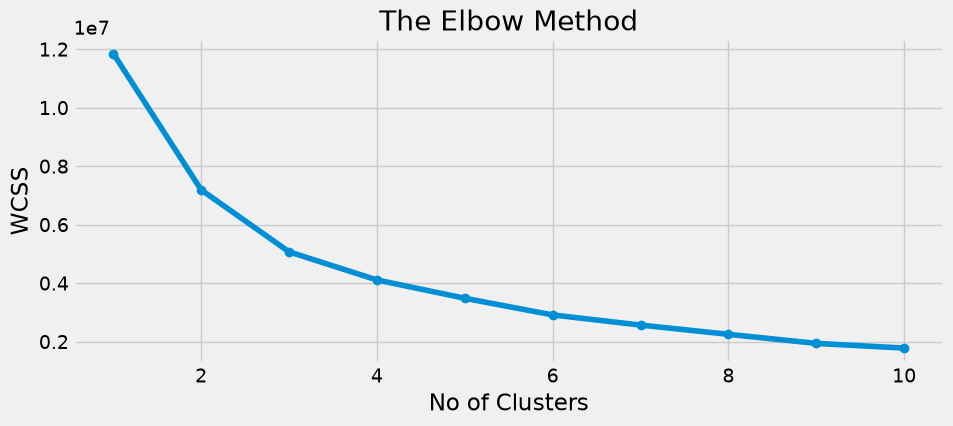

In [53]:
plt.plot(range(1,11), wcss, marker='o')

plt.title("The Elbow Method", fontsize=20)

plt.xlabel("No of Clusters")

plt.ylabel("WCSS")

plt.show()

### Observation

The Elbow Method was used to determine the optimal number of clusters. Based on the WCSS graph, four clusters were selected for K-Means clustering.

In [54]:
km = KMeans(
    n_clusters=4,
    init='k-means++',
    max_iter=300,
    n_init=10,
    random_state=0
)

y_means = km.fit_predict(x)

In [55]:
cluster_df = pd.DataFrame(y_means, columns=['cluster'])

result = pd.concat(
    [cluster_df, df['label'].reset_index(drop=True)],
    axis=1
)

result.head()

,cluster,label
0,2,rice
1,2,rice
2,2,rice
3,2,rice
4,2,rice


In [56]:
print("Let's check the results after applying K-Means Clustering\n")

print("Crops in First Cluster:")
print(result[result['cluster']==0]['label'].unique())

print()

print("Crops in Second Cluster:")
print(result[result['cluster']==1]['label'].unique())

print()

print("Crops in Third Cluster:")
print(result[result['cluster']==2]['label'].unique())

print()

print("Crops in Fourth Cluster:")
print(result[result['cluster']==3]['label'].unique())

Let's check the results after applying K-Means Clustering

Crops in First Cluster:
<StringArray>
[      'maize',    'chickpea', 'kidneybeans',  'pigeonpeas',   'mothbeans',
    'mungbean',   'blackgram',      'lentil',      'grapes',       'apple',
      'papaya']
Length: 11, dtype: str

Crops in Second Cluster:
<StringArray>
['maize', 'banana', 'watermelon', 'muskmelon', 'papaya', 'cotton', 'coffee']
Length: 7, dtype: str

Crops in Third Cluster:
<StringArray>
['rice', 'pigeonpeas', 'papaya', 'coconut', 'jute', 'coffee']
Length: 6, dtype: str

Crops in Fourth Cluster:
<StringArray>
[      'maize', 'kidneybeans',  'pigeonpeas', 'pomegranate',       'mango',
      'orange',      'papaya',     'coconut',      'coffee']
Length: 9, dtype: str


### Observation

The K-Means algorithm grouped crops into four clusters based on similar environmental conditions. These clusters help identify agricultural patterns useful for crop recommendation.

## Story 2: Logistic Regression

### Objective

Logistic Regression is used to classify crops based on agricultural features. The model is trained using the training dataset and predictions are generated using the testing dataset.

In [90]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(n_estimators=100, random_state=0)

rf.fit(x_train, y_train)

rf_pred = rf.predict(x_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.9975786924939467


In [91]:
print(rf.predict(x.iloc[[0]]))
print(df.iloc[0]["label"])

['rice']
rice


### Observation

The Logistic Regression model was successfully trained using the training dataset and generated crop predictions for the testing dataset.

## Story 3: Evaluating Model Performance and Saving the Best Model

### Objective

The trained model is evaluated using various classification metrics to determine prediction accuracy. After evaluation, the best-performing model is saved using Pickle for deployment.

In [72]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import pickle

In [73]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.9539951573849879


In [74]:
cr = classification_report(y_test, y_pred)

print(cr)

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00         4
      banana       1.00      1.00      1.00        22
   blackgram       0.95      0.95      0.95        21
    chickpea       1.00      1.00      1.00        24
     coconut       1.00      1.00      1.00        19
      coffee       1.00      1.00      1.00        20
      cotton       0.91      0.91      0.91        22
      grapes       1.00      1.00      1.00         6
        jute       0.93      0.82      0.88        17
 kidneybeans       0.91      1.00      0.95        20
      lentil       0.94      1.00      0.97        17
       maize       0.88      0.88      0.88        17
       mango       0.95      1.00      0.98        21
   mothbeans       0.96      0.85      0.90        26
    mungbean       0.80      0.92      0.86        13
   muskmelon       1.00      1.00      1.00        14
      orange       1.00      1.00      1.00        25
      papaya       0.86    

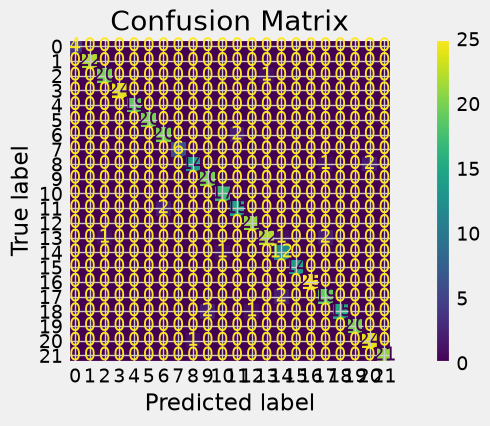

In [75]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Confusion Matrix")

plt.show()

In [76]:
with open("../model/model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully!")

Model saved successfully!


In [77]:
with open("../model/model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

print(loaded_model)

LogisticRegression(max_iter=1000)


### Observation

The model achieved good prediction accuracy and was successfully saved as **model.pkl**. This saved model will be used in the Flask web application to generate crop recommendations.

## Story 4: Predict the Best Crop Based on Given Parameters

### Objective

The trained machine learning model predicts the most suitable crop based on soil nutrients and environmental conditions provided by the user.

In [78]:
sample = np.array([[105, 35, 40, 25, 64, 7, 160]])

In [79]:
prediction = model.predict(sample)

c:\Users\KUSHAL SAI KUMAR\Desktop\OptiCrop\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [80]:
print("The suggested crop for the given climatic condition is:", prediction[0])

The suggested crop for the given climatic condition is: pomegranate


### Observation

The trained Logistic Regression model successfully predicted the most suitable crop based on the given soil and environmental parameters. This demonstrates the practical application of machine learning for intelligent crop recommendation.

In [92]:
import pickle

pickle.dump(rf, open("../model/model.pkl", "wb"))

print("Random Forest model saved successfully!")

Random Forest model saved successfully!
